# Figures Meteo

in this notebook various parts of the climatology and meteorology are visualized


In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.lines import Line2D

## precip climatology
makes a figure that shows differences in precipition within the basin


### bar chart 2 locations
shows the monthly precipiton for 2 locations

In [2]:
file_name_pr = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_5570/AralSeaBasin/pcrglobwb/work/diagnostic/script/pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1955-1970_AralSeaBasin.nc"

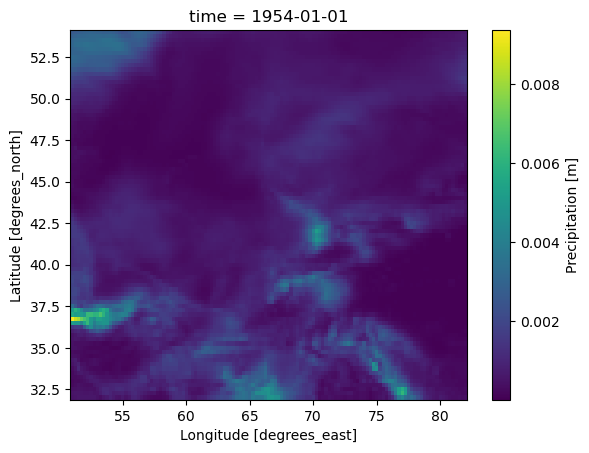

In [3]:
# open the file
ds = xr.open_dataset(file_name_pr)


# quick plot
ds["pr"].isel(time=0).plot()

In [4]:
# extract time series at nearest grid point
ts_1 = ds["pr"].sel(lat=38.9, lon=69, method="nearest")
ts_2 = ds["pr"].sel(lat=45.7, lon=63.3, method="nearest")
# monthly total (sum of daily values per month), convert m → mm
ts1_mm_month = ts_1.resample(time="ME").sum() * 1000
ts2_mm_month = ts_2.resample(time="ME").sum() * 1000

# climatology: average monthly pattern across years
clim_monthly_1 = ts1_mm_month.groupby("time.month").mean("time")
clim_monthly_2 = ts2_mm_month.groupby("time.month").mean("time")

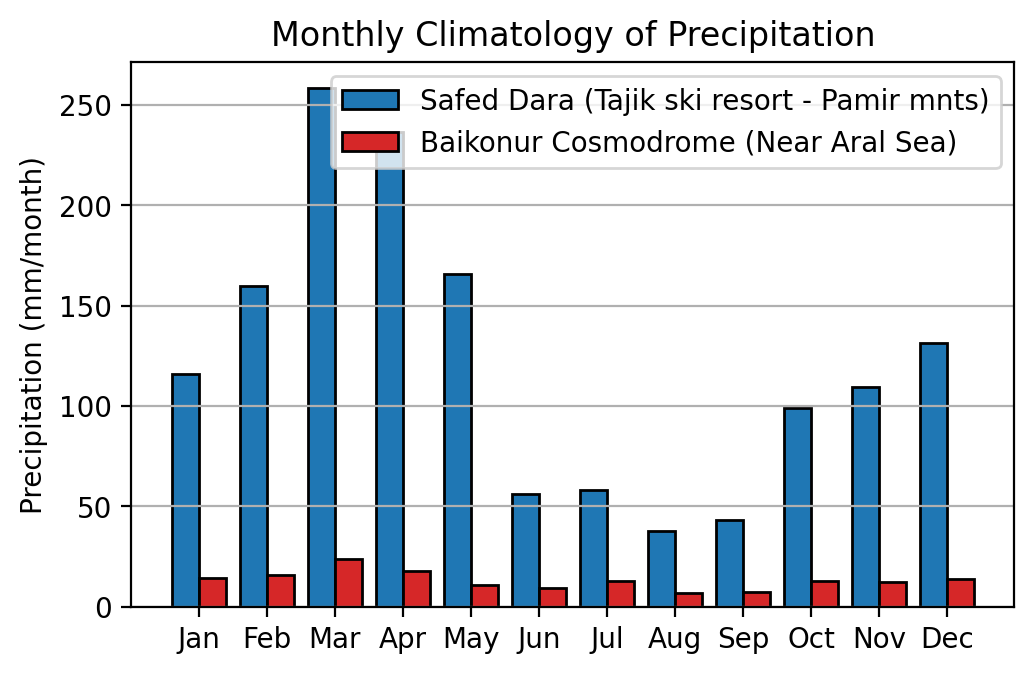

In [5]:
# months 1–12
months = np.arange(1, 13)

# bar width and positions
bar_width = 0.4
x = np.arange(len(months))

fig, ax = plt.subplots(figsize=(5, 3.2), dpi=200)

ax.bar(
    x - bar_width / 2,
    clim_monthly_1.values,
    width=bar_width,
    label="Safed Dara (Tajik ski resort - Pamir mnts)",
    color="tab:blue",
    edgecolor="black",
)
ax.bar(
    x + bar_width / 2,
    clim_monthly_2.values,
    width=bar_width,
    label="Baikonur Cosmodrome (Near Aral Sea)",
    color="tab:red",
    edgecolor="black",
)

ax.set_xticks(x)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_ylabel("Precipitation (mm/month)")
ax.set_title("Monthly Climatology of Precipitation")
ax.legend()
ax.grid(axis="y")
fig.tight_layout(pad=0.1)
plt.savefig(
    "../../outputs/figures/precip_difference.png", bbox_inches="tight", pad_inches=0.05, dpi=200
)
plt.show()

### contour plot for whole basin
plots contour plot

In [6]:
# convert to dataArray
da = ds["pr"]

# convert to mm/year and take average
da_yearly = da.resample(time="1YE").sum(dim="time") * 1000
da_avg_year = da_yearly.mean(dim="time")  # average yearly precipitation

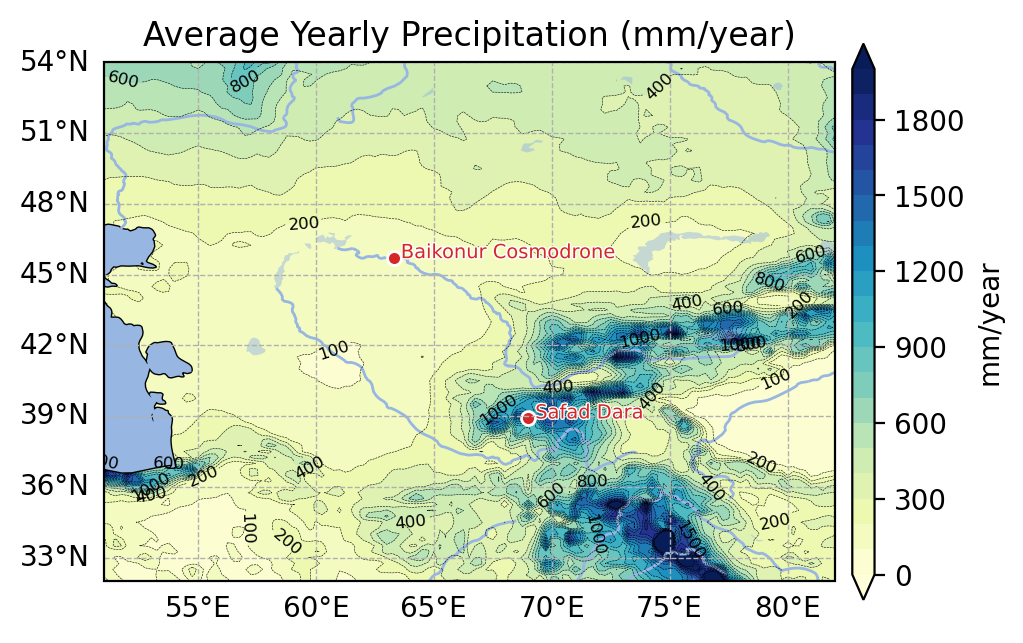

In [7]:
# Define min and max for plotting levels
vmin = 0  # mm/year
vmax = 2000  # mm/year
n_levels = 21
levels = np.linspace(vmin, vmax, n_levels)


fig, ax = plt.subplots(figsize=(5, 4), dpi=200, subplot_kw={"projection": ccrs.PlateCarree()})

# Filled contours
im = ax.contourf(
    da_avg_year["lon"],
    da_avg_year["lat"],
    da_avg_year,
    levels=levels,
    cmap="YlGnBu",
    extend="both",  # adds arrows if values go below vmin or above vmax
)

# Contour lines
cs = ax.contour(
    da_avg_year["lon"],
    da_avg_year["lat"],
    da_avg_year,
    levels=levels,  # same levels as filled contours
    colors="k",  # line color
    linewidths=0.2,  # thickness
    linestyles="--",  # dashed lines (optional)
)

# Add labels to contour lines (for custom levels for readability)
custom_levels = [100, 200, 400, 600, 800, 1000, 1500]

ax.clabel(cs, levels=custom_levels, inline=True, fmt="%.0f", fontsize=6)

lat1, lon1 = 38.9, 69  # handpicked location 1
lat2, lon2 = 45.7, 63.3  # handpicked location 2


# Create a marker with white outline for virtual stations
marker1 = Line2D(
    [lon1],
    [lat1],
    marker="o",
    color="tab:red",
    markersize=5,
    transform=ccrs.PlateCarree(),
    markeredgecolor="white",
    markeredgewidth=1,
)
ax.add_line(marker1)

marker2 = Line2D(
    [lon2],
    [lat2],
    marker="o",
    color="tab:red",
    markersize=5,
    transform=ccrs.PlateCarree(),
    markeredgecolor="white",
    markeredgewidth=1,
)
ax.add_line(marker2)

# Add text labels
ax.text(
    lon1 + 0.3,
    lat1,
    "Safad Dara",
    transform=ccrs.PlateCarree(),
    fontsize=7,
    color="tab:red",
    path_effects=[pe.withStroke(linewidth=1, foreground="white")],  # white outline
)
ax.text(
    lon2 + 0.3,
    lat2,
    "Baikonur Cosmodrone",
    transform=ccrs.PlateCarree(),
    fontsize=7,
    color="tab:red",
    path_effects=[pe.withStroke(linewidth=1, foreground="white")],  # white outline
)


# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.RIVERS)
ax.set_title("Average Yearly Precipitation (mm/year)")

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    shrink=0.7,  # 70% of figure height
    aspect=25,  # thinner
    pad=0.02,
)  # distance to map
cbar.set_label("mm/year")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


fig.tight_layout(pad=0.1)
plt.savefig(
    "../../outputs/figures/precip_contour.png", bbox_inches="tight", pad_inches=0.05, dpi=200
)
plt.show()

In [ ]:
da = ds["pr"]
da_yearly = da.resample(time="1YE").sum(dim="time") * 1000
da_avg_year = da_yearly.mean(dim="time")

stations = [
    {"lat": 38.9, "lon": 69, "name": "Safad Dara"},
    {"lat": 45.7, "lon": 63.3, "name": "Baikonur Cosmodrome"},
]

plot_precipitation_map(
    da_avg_year,
    contour_lines=[100, 200, 400, 600, 800, 1000, 1500],
    stations=stations,
)